# Courbes de loss — entraînements baseline DDPM et GAN

Lit les logs CSV produits par `src/training/train_ddpm.py` et `src/training/train_gan.py` (checklist "Entraînement baseline (DDPM + GAN)" de `TASKS.md`) et visualise les courbes de loss pour vérifier la convergence (DDPM) et repérer un éventuel mode collapse (GAN).

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().parent
ddpm_log = pd.read_csv(root / "experiments" / "ddpm_baseline" / "log.csv")
gan_log = pd.read_csv(root / "experiments" / "gan_baseline" / "log.csv")

print("DDPM :", ddpm_log.shape, "— durée totale :", ddpm_log['elapsed_s'].iloc[-1], "s")
print("GAN  :", gan_log.shape, "— durée totale :", gan_log['elapsed_s'].iloc[-1], "s")

DDPM : (101, 3) — durée totale : 7235.61 s
GAN  : (101, 6) — durée totale : 1012.52 s


## DDPM — loss MSE (bruit prédit vs réel)

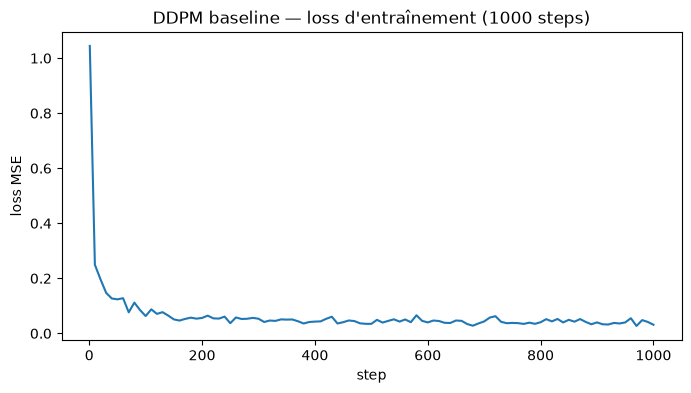

Loss step 1 : 1.0444
Loss moyenne des 20 derniers logs : 0.0414


In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ddpm_log["step"], ddpm_log["loss"])
ax.set_xlabel("step")
ax.set_ylabel("loss MSE")
ax.set_title("DDPM baseline — loss d'entraînement (1000 steps)")
plt.show()

print(f"Loss step 1 : {ddpm_log['loss'].iloc[0]:.4f}")
print(f"Loss moyenne des 20 derniers logs : {ddpm_log['loss'].tail(20).mean():.4f}")

## GAN — loss générateur/discriminateur et scores D(real)/D(fake)

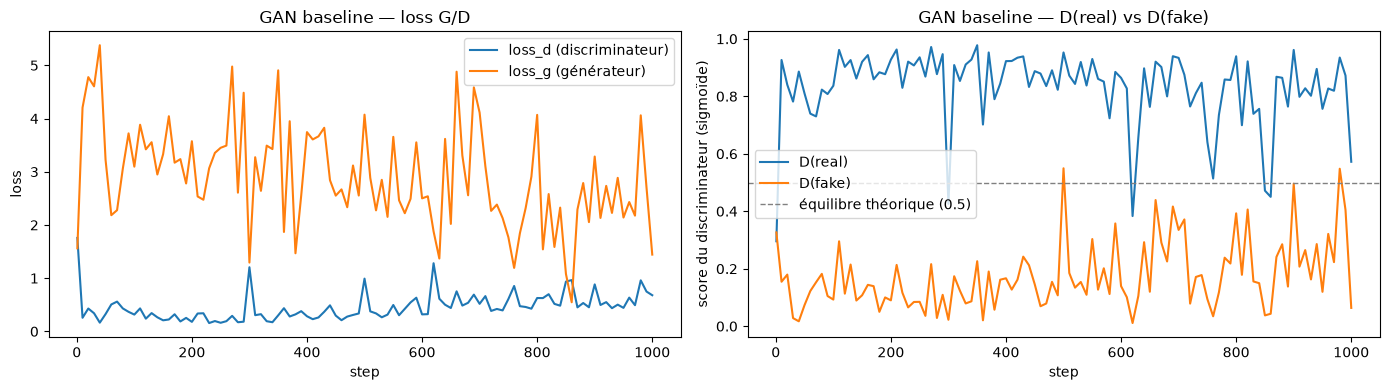

loss_d step1=1.757 -> moy. 20 derniers=0.624
loss_g step1=1.562 -> moy. 20 derniers=2.251
D(real) step1=0.296 -> moy. 20 derniers=0.780
D(fake) step1=0.326 -> moy. 20 derniers=0.237


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(gan_log["step"], gan_log["loss_d"], label="loss_d (discriminateur)")
axes[0].plot(gan_log["step"], gan_log["loss_g"], label="loss_g (générateur)")
axes[0].set_xlabel("step")
axes[0].set_ylabel("loss")
axes[0].set_title("GAN baseline — loss G/D")
axes[0].legend()

axes[1].plot(gan_log["step"], gan_log["d_real_mean"], label="D(real)")
axes[1].plot(gan_log["step"], gan_log["d_fake_mean"], label="D(fake)")
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=1, label="équilibre théorique (0.5)")
axes[1].set_xlabel("step")
axes[1].set_ylabel("score du discriminateur (sigmoïde)")
axes[1].set_title("GAN baseline — D(real) vs D(fake)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"loss_d step1={gan_log['loss_d'].iloc[0]:.3f} -> moy. 20 derniers={gan_log['loss_d'].tail(20).mean():.3f}")
print(f"loss_g step1={gan_log['loss_g'].iloc[0]:.3f} -> moy. 20 derniers={gan_log['loss_g'].tail(20).mean():.3f}")
print(f"D(real) step1={gan_log['d_real_mean'].iloc[0]:.3f} -> moy. 20 derniers={gan_log['d_real_mean'].tail(20).mean():.3f}")
print(f"D(fake) step1={gan_log['d_fake_mean'].iloc[0]:.3f} -> moy. 20 derniers={gan_log['d_fake_mean'].tail(20).mean():.3f}")

## Observations — stabilité d'entraînement (base de la section "Résultats"/"Discussion" du rapport)

- **DDPM** : décroissance stable et monotone de la loss (1.044 → ~0.041), sans oscillation ni divergence. Comportement attendu et sain pour ce type d'objectif (régression du bruit).
- **GAN** : dynamique nettement plus instable, comme attendu pour un jeu adversarial. `D(real)` grimpe progressivement vers ~0.78 tandis que `D(fake)` reste autour de 0.20-0.30 : le discriminateur prend l'avantage sur le générateur (déséquilibre), avec des pics ponctuels de `loss_g` (jusqu'à ~5.4) — signe d'instabilité plutôt que de convergence lisse, mais **pas de mode collapse total** (les échantillons visuels restent variés en forme, cf. `experiments/gan_baseline/samples/`).
- Les échantillons GAN présentent des artefacts en damier ("checkerboard"), un défaut connu des couches `ConvTranspose2d` (cf. Odena et al., *Deconvolution and Checkerboard Artifacts*, 2016) — à mentionner dans la section Discussion/Limites du rapport.
- **Comparaison de stabilité** : le DDPM converge de façon prévisible et reproductible ; le GAN nécessite un suivi plus attentif (risque d'oscillation/collapse), confirmant la littérature (Ho et al. 2020 vs Goodfellow et al. 2014) sur la stabilité comparée des deux familles de modèles génératifs.